### Cell 1: Import thư viện

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Flatten

### Cell 2: Load Fashion MNIST

In [ ]:
fashion_mnist = keras.datasets.fashion_mnist

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

print("Classes:", np.unique(y_train))

X_train shape: (60000, 28, 28)
y_train shape: (60000,)
X_test shape: (10000, 28, 28)
y_test shape: (10000,)
Classes: [0 1 2 3 4 5 6 7 8 9]


### Cell 3: Tên các nhãn

In [ ]:
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

### Cell 4: Xem ảnh mẫu

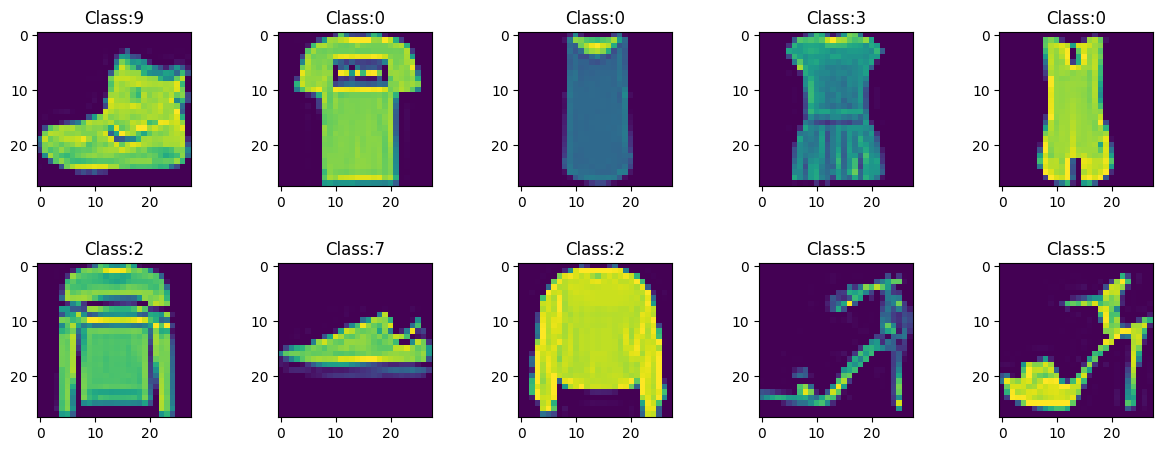

In [ ]:
#Data visualization
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(15, 5))
ax = axes.ravel()
for i in range(10):
    ax[i].imshow(X_train[i].reshape(28, 28))
    ax[i].title.set_text('Class:'+str(y_train[i]))
plt.subplots_adjust(hspace=0.5)
plt.show()

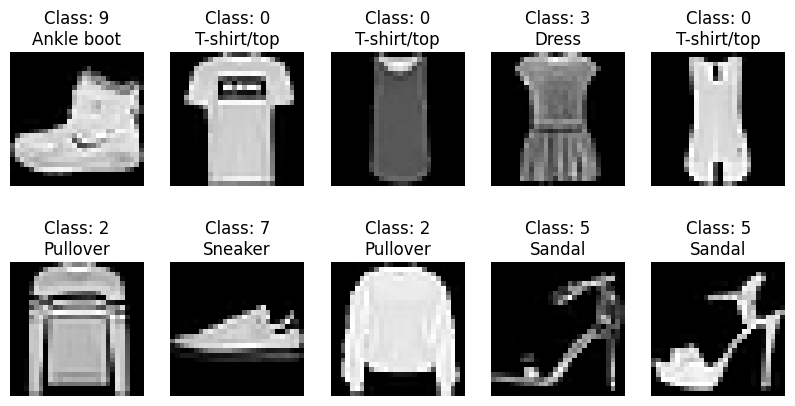

In [ ]:
plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Class: {y_train[i]}\n{class_names[y_train[i]]}")
    plt.axis("off")

plt.show()

### Cell 5: Scale dữ liệu

In [ ]:
print("Before scaling:")
print("Min:", X_train.min())
print("Max:", X_train.max())

X_train = X_train / 255.0
X_test = X_test / 255.0

print("\nAfter scaling:")
print("Min:", X_train.min())
print("Max:", X_train.max())

Before scaling:
Min: 0
Max: 255

After scaling:
Min: 0.0
Max: 1.0


### Cell 6: Xây dựng mô hình ANN

In [ ]:
model = Sequential()

model.add(
    Flatten(input_shape=(28, 28))
)

model.add(
    Dense(
        units=256,
        activation="relu",
        kernel_initializer="uniform"
    )
)

model.add(
    Dense(
        units=10,
        activation="softmax",
        kernel_initializer="uniform"
    )
)

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,530 (795.04 KB)

 Trainable params: 203,530 (795.04 KB)

 Non-trainable params: 0 (0.00 B)

### Cell 7: Huấn luyện mô hình

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.8226 - loss: 0.4980 - val_accuracy: 0.8463 - val_loss: 0.4259
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8670 - loss: 0.3642 - val_accuracy: 0.8611 - val_loss: 0.3920
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - accuracy: 0.8793 - loss: 0.3276 - val_accuracy: 0.8522 - val_loss: 0.3861
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8868 - loss: 0.3053 - val_accuracy: 0.8707 - val_loss: 0.3610
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8934 - loss: 0.2872 - val_accuracy: 0.8807 - val_loss: 0.3297
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.8988 - loss: 0.2720 - val_accuracy: 0.8752 - val_loss: 0.3482
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9039 - loss: 0.2582 - val_accuracy: 0.8757 - val_loss: 0.3454
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9074 - loss: 0

### Cell 8: Vẽ biểu đồ Accuracy

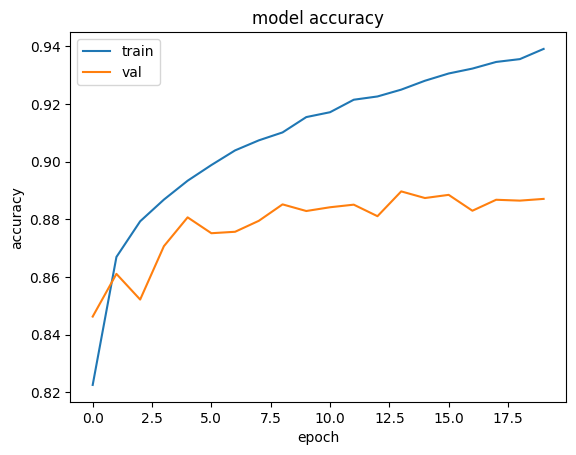

In [ ]:
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="val")
plt.title("model accuracy")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.legend(loc="upper left")
plt.show()

### Cell 9: Vẽ biểu đồ Loss

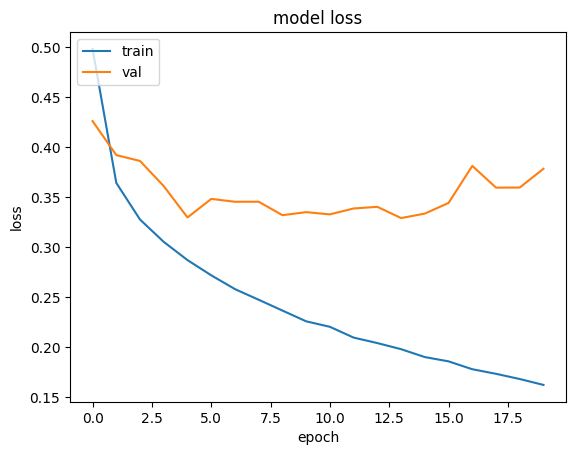

In [ ]:
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.title("model loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend(loc="upper left")
plt.show()

### Cell 10: Đánh giá model

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8871 - loss: 0.3783
Test Loss: 0.37834686040878296
Test Accuracy: 0.8870999813079834


### Cell 11: Dự đoán ảnh mới trong tập test

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Predicted label: 9 - Ankle boot
Real label: 9 - Ankle boot


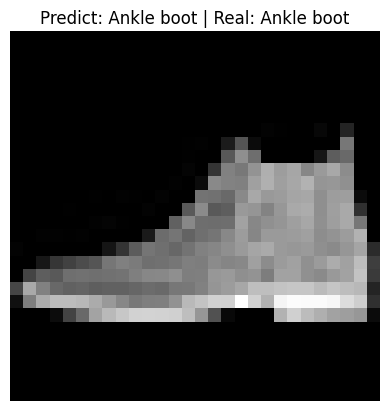

In [ ]:
predictions = model.predict(X_test)

index = 0

predicted_label = np.argmax(predictions[index])
real_label = y_test[index]

print("Predicted label:", predicted_label, "-", class_names[predicted_label])
print("Real label:", real_label, "-", class_names[real_label])

plt.imshow(X_test[index], cmap="gray")
plt.title(f"Predict: {class_names[predicted_label]} | Real: {class_names[real_label]}")
plt.axis("off")
plt.show()

### Cell 12: Xem nhiều ảnh dự đoán

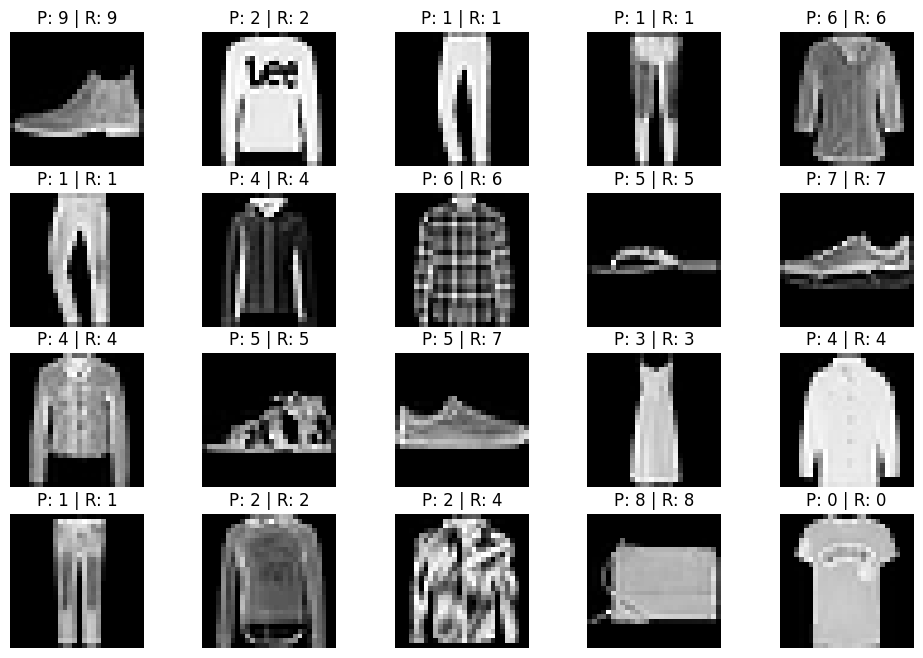

In [ ]:
plt.figure(figsize=(12, 8))

for i in range(20):
    pred = np.argmax(predictions[i])
    real = y_test[i]

    plt.subplot(4, 5, i + 1)
    plt.imshow(X_test[i], cmap="gray")
    plt.title(f"P: {pred} | R: {real}")
    plt.axis("off")

plt.show()

Dưới đây là **Bài 1: ANN nhận dạng ảnh CIFAR10** dựa theo code bài mẫu Fashion MNIST trong lab. CIFAR10 có 10 nhãn: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck.

## Cell 1: Import thư viện

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Flatten

## Cell 2: Load dataset CIFAR10

In [ ]:
cifar10 = keras.datasets.cifar10

(X_train, y_train), (X_test, y_test) = cifar10.load_data()

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

print("Classes:", np.unique(y_train))

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
X_train shape: (50000, 32, 32, 3)
y_train shape: (50000, 1)
X_test shape: (10000, 32, 32, 3)
y_test shape: (10000, 1)
Classes: [0 1 2 3 4 5 6 7 8 9]


## Cell 3: Tên nhãn

In [ ]:
class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

## Cell 4: Hiển thị ảnh mẫu

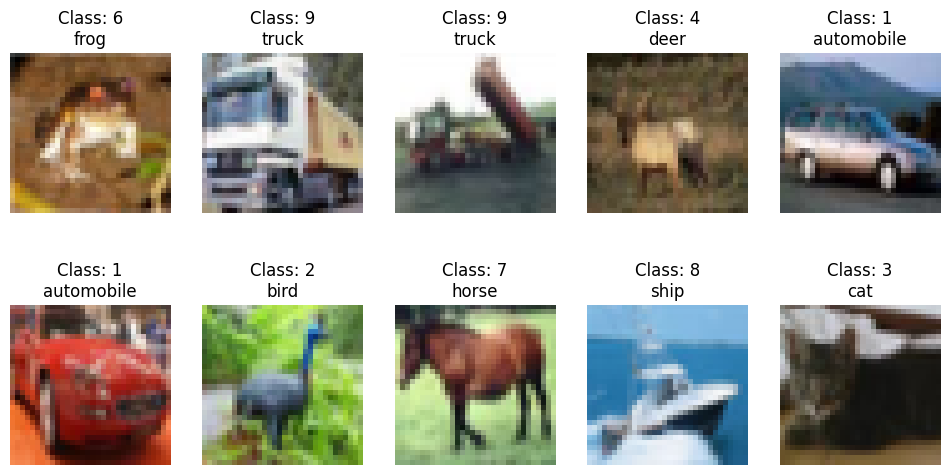

In [ ]:
plt.figure(figsize=(12, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i])
    label = y_train[i][0]
    plt.title(f"Class: {label}\n{class_names[label]}")
    plt.axis("off")

plt.show()

## Cell 5: Scale dữ liệu

In [ ]:
print("Before scaling:")
print("Min:", X_train.min())
print("Max:", X_train.max())

X_train = X_train / 255.0
X_test = X_test / 255.0

print("\nAfter scaling:")
print("Min:", X_train.min())
print("Max:", X_train.max())

Before scaling:
Min: 0
Max: 255

After scaling:
Min: 0.0
Max: 1.0


## Cell 6: Xây dựng ANN model

In [ ]:
model = Sequential()

model.add(
    Flatten(input_shape=(32, 32, 3))
)

model.add(
    Dense(
        units=512,
        activation="relu",
        kernel_initializer="uniform"
    )
)

model.add(
    Dense(
        units=256,
        activation="relu",
        kernel_initializer="uniform"
    )
)

model.add(
    Dense(
        units=10,
        activation="softmax",
        kernel_initializer="uniform"
    )
)

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,707,274 (6.51 MB)

 Trainable params: 1,707,274 (6.51 MB)

 Non-trainable params: 0 (0.00 B)

## Cell 7: Train model

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 39s 24ms/step - accuracy: 0.3347 - loss: 1.8324 - val_accuracy: 0.3645 - val_loss: 1.7460
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 38s 24ms/step - accuracy: 0.4022 - loss: 1.6629 - val_accuracy: 0.4264 - val_loss: 1.6007
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 37s 24ms/step - accuracy: 0.4359 - loss: 1.5754 - val_accuracy: 0.4336 - val_loss: 1.5724
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 39s 25ms/step - accuracy: 0.4518 - loss: 1.5245 - val_accuracy: 0.4584 - val_loss: 1.5013
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 43s 26ms/step - accuracy: 0.4675 - loss: 1.4864 - val_accuracy: 0.4662 - val_loss: 1.5031
Epoch 6/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 42s 27ms/step - accuracy: 0.4791 - loss: 1.4507 - val_accuracy: 0.4662 - val_loss: 1.4790
Epoch 7/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 38s 24ms/step - accuracy: 0.4896 - loss: 1.4232 - val_accuracy: 0.4832 - val_loss: 1.4624
Epoch 8/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 37s 24ms/step - accuracy: 0.4989 -

## Cell 8: Vẽ biểu đồ Accuracy

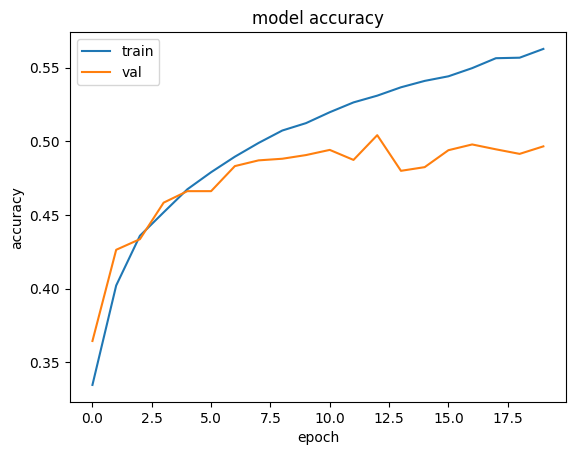

In [ ]:
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="val")

plt.title("model accuracy")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.legend(loc="upper left")
plt.show()

## Cell 9: Vẽ biểu đồ Loss

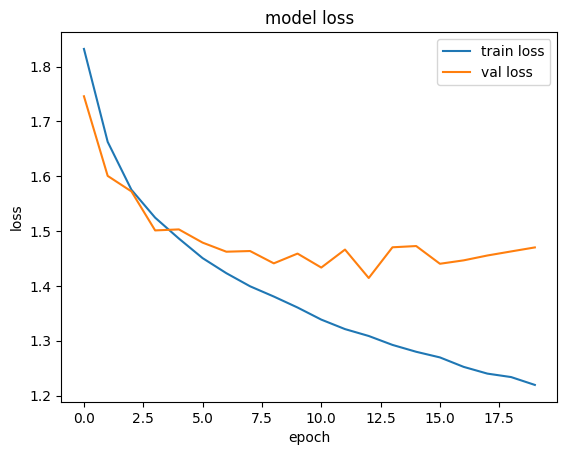

In [ ]:
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")

plt.title("model loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend(loc="upper right")
plt.show()

## Cell 10: Đánh giá model

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4966 - loss: 1.4702
Test Loss: 1.4702297449111938
Test Accuracy: 0.4966000020503998


## Cell 11: Dự đoán 1 ảnh

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
Predicted: 1 - automobile
Real: 3 - cat


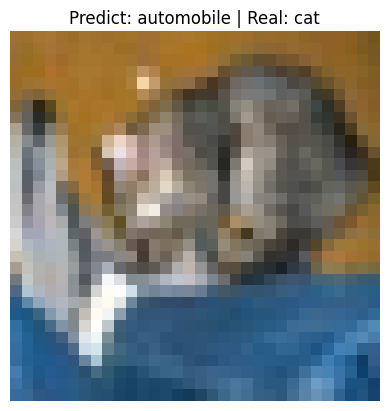

In [ ]:
predictions = model.predict(X_test)

index = 0

predicted_label = np.argmax(predictions[index])
real_label = y_test[index][0]

print("Predicted:", predicted_label, "-", class_names[predicted_label])
print("Real:", real_label, "-", class_names[real_label])

plt.imshow(X_test[index])
plt.title(
    f"Predict: {class_names[predicted_label]} | Real: {class_names[real_label]}"
)
plt.axis("off")
plt.show()

## Cell 12: Hiển thị nhiều ảnh dự đoán

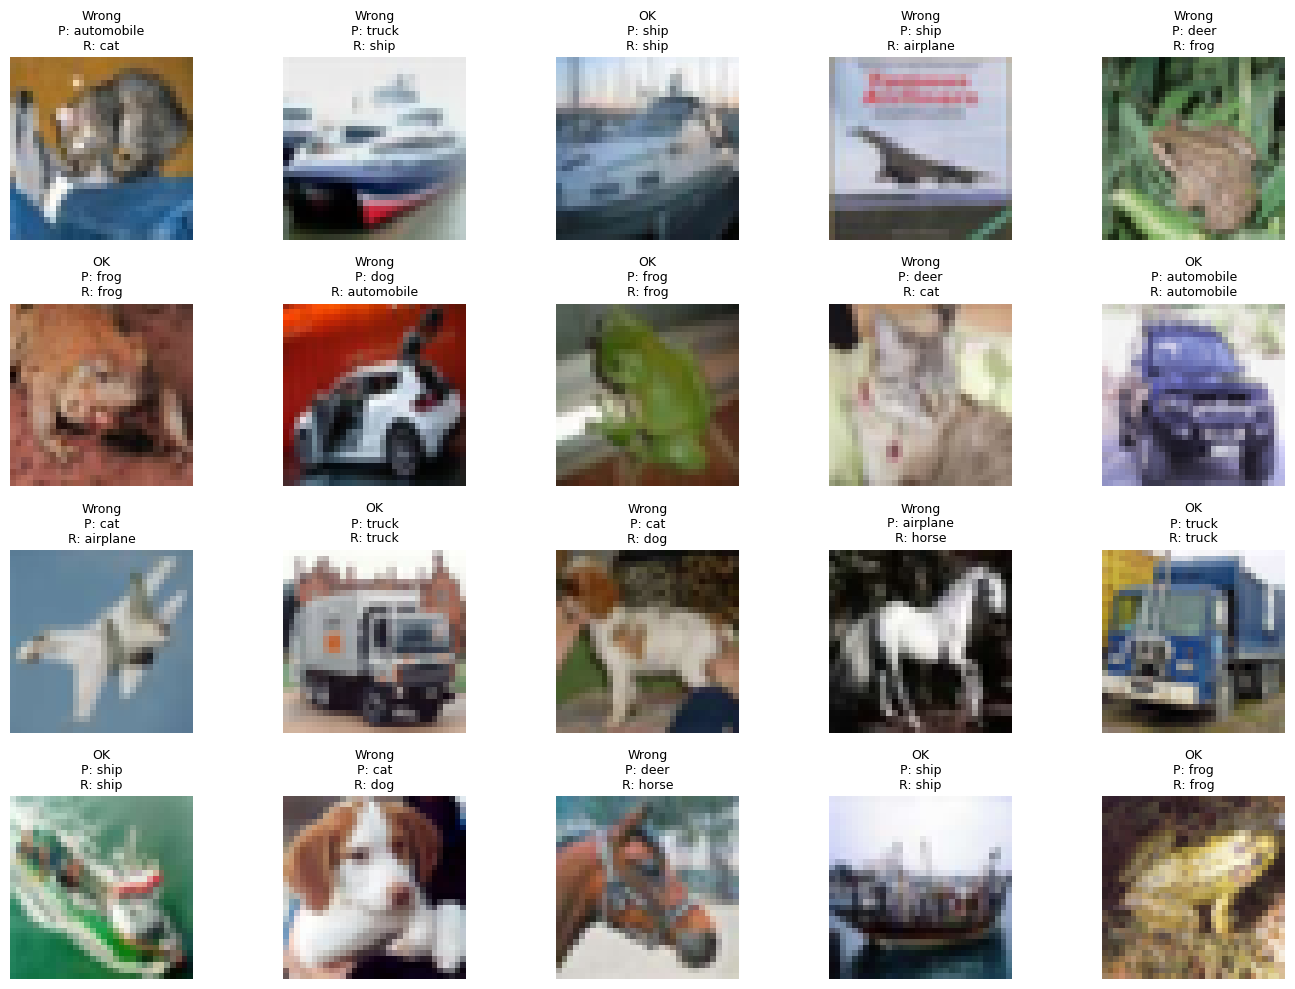

In [ ]:
plt.figure(figsize=(14, 10))

for i in range(20):
    pred = np.argmax(predictions[i])
    real = y_test[i][0]

    plt.subplot(4, 5, i + 1)
    plt.imshow(X_test[i])

    if pred == real:
        title = f"OK\nP: {class_names[pred]}\nR: {class_names[real]}"
    else:
        title = f"Wrong\nP: {class_names[pred]}\nR: {class_names[real]}"

    plt.title(title, fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()

Bạn vừa làm **bài 2 MNIST có sẵn trong TensorFlow** rồi.

Trong file lab, **bài 2 yêu cầu MNIST do giảng viên cung cấp** , nên mình viết thêm bản **đọc ảnh từ thư mục**.

## Cấu trúc thư mục trên Colab

```text
/content/MNIST/
├── train/
│   ├── 0/
│   ├── 1/
│   ├── ...
│   └── 9/
└── test/
    ├── 0/
    ├── 1/
    ├── ...
    └── 9/
```

## Cell 1: Import thư viện

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Flatten

In [ ]:
import os
import cv2 # Using OpenCV to save images

# Install OpenCV if not already installed
try:
    import cv2
except ImportError:
    !pip install opencv-python-headless
    import cv2

# Load MNIST dataset
(x_train_raw, y_train_raw), (x_test_raw, y_test_raw) = tf.keras.datasets.mnist.load_data()

# Define base directory for MNIST data
base_mnist_dir = "/content/MNIST"

# Create train and test directories
train_dir = os.path.join(base_mnist_dir, "train")
test_dir = os.path.join(base_mnist_dir, "test")
os.makedirs(train_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

print(f"Created directory: {train_dir}")
print(f"Created directory: {test_dir}")

# Function to save images to the appropriate directories
def save_images(images, labels, base_save_dir):
    for i in range(len(images)):
        label = labels[i]
        image = images[i]

        # Create subfolder for the current label if it doesn't exist
        label_dir = os.path.join(base_save_dir, str(label))
        os.makedirs(label_dir, exist_ok=True)

        # Save the image (OpenCV expects 8-bit images for saving)
        image_filename = os.path.join(label_dir, f"image_{i:05d}.png")
        cv2.imwrite(image_filename, image)
    print(f"Saved {len(images)} images to {base_save_dir}")

# Save training images
save_images(x_train_raw, y_train_raw, train_dir)

# Save testing images
save_images(x_test_raw, y_test_raw, test_dir)

print("MNIST dataset preparation complete.")

In [ ]:
import os
import cv2 # Using OpenCV to save images

# Install OpenCV if not already installed
try:
    import cv2
except ImportError:
    !pip install opencv-python-headless
    import cv2

# Load MNIST dataset
(x_train_raw, y_train_raw), (x_test_raw, y_test_raw) = tf.keras.datasets.mnist.load_data()

# Define base directory for MNIST data
base_mnist_dir = "/content/MNIST"

# Create train and test directories
train_dir = os.path.join(base_mnist_dir, "train")
test_dir = os.path.join(base_mnist_dir, "test")
os.makedirs(train_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

print(f"Created directory: {train_dir}")
print(f"Created directory: {test_dir}")

# Function to save images to the appropriate directories
def save_images(images, labels, base_save_dir):
    for i in range(len(images)):
        label = labels[i]
        image = images[i]

        # Create subfolder for the current label if it doesn't exist
        label_dir = os.path.join(base_save_dir, str(label))
        os.makedirs(label_dir, exist_ok=True)

        # Save the image (OpenCV expects 8-bit images for saving)
        image_filename = os.path.join(label_dir, f"image_{i:05d}.png")
        cv2.imwrite(image_filename, image)
    print(f"Saved {len(images)} images to {base_save_dir}")

# Save training images
save_images(x_train_raw, y_train_raw, train_dir)

# Save testing images
save_images(x_test_raw, y_test_raw, test_dir)

print("MNIST dataset preparation complete.")

In [ ]:
import os
import cv2 # Using OpenCV to save images

# Install OpenCV if not already installed
try:
    import cv2
except ImportError:
    !pip install opencv-python-headless
    import cv2

# Load MNIST dataset
(x_train_raw, y_train_raw), (x_test_raw, y_test_raw) = tf.keras.datasets.mnist.load_data()

# Define base directory for MNIST data
base_mnist_dir = "/content/MNIST"

# Create train and test directories
train_dir = os.path.join(base_mnist_dir, "train")
test_dir = os.path.join(base_mnist_dir, "test")
os.makedirs(train_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

print(f"Created directory: {train_dir}")
print(f"Created directory: {test_dir}")

# Function to save images to the appropriate directories
def save_images(images, labels, base_save_dir):
    for i in range(len(images)):
        label = labels[i]
        image = images[i]

        # Create subfolder for the current label if it doesn't exist
        label_dir = os.path.join(base_save_dir, str(label))
        os.makedirs(label_dir, exist_ok=True)

        # Save the image (OpenCV expects 8-bit images for saving)
        image_filename = os.path.join(label_dir, f"image_{i:05d}.png")
        cv2.imwrite(image_filename, image)
    print(f"Saved {len(images)} images to {base_save_dir}")

# Save training images
save_images(x_train_raw, y_train_raw, train_dir)

# Save testing images
save_images(x_test_raw, y_test_raw, test_dir)

print("MNIST dataset preparation complete.")

In [ ]:
import os
import cv2 # Using OpenCV to save images

# Install OpenCV if not already installed
try:
    import cv2
except ImportError:
    !pip install opencv-python-headless
    import cv2

# Load MNIST dataset
(x_train_raw, y_train_raw), (x_test_raw, y_test_raw) = tf.keras.datasets.mnist.load_data()

# Define base directory for MNIST data
base_mnist_dir = "/content/MNIST"

# Create train and test directories
train_dir = os.path.join(base_mnist_dir, "train")
test_dir = os.path.join(base_mnist_dir, "test")
os.makedirs(train_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

print(f"Created directory: {train_dir}")
print(f"Created directory: {test_dir}")

# Function to save images to the appropriate directories
def save_images(images, labels, base_save_dir):
    for i in range(len(images)):
        label = labels[i]
        image = images[i]

        # Create subfolder for the current label if it doesn't exist
        label_dir = os.path.join(base_save_dir, str(label))
        os.makedirs(label_dir, exist_ok=True)

        # Save the image (OpenCV expects 8-bit images for saving)
        image_filename = os.path.join(label_dir, f"image_{i:05d}.png")
        cv2.imwrite(image_filename, image)
    print(f"Saved {len(images)} images to {base_save_dir}")

# Save training images
save_images(x_train_raw, y_train_raw, train_dir)

# Save testing images
save_images(x_test_raw, y_test_raw, test_dir)

print("MNIST dataset preparation complete.")

In [ ]:
import os
import cv2 # Using OpenCV to save images

# Install OpenCV if not already installed
try:
    import cv2
except ImportError:
    !pip install opencv-python-headless
    import cv2

# Load MNIST dataset
(x_train_raw, y_train_raw), (x_test_raw, y_test_raw) = tf.keras.datasets.mnist.load_data()

# Define base directory for MNIST data
base_mnist_dir = "/content/MNIST"

# Create train and test directories
train_dir = os.path.join(base_mnist_dir, "train")
test_dir = os.path.join(base_mnist_dir, "test")
os.makedirs(train_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

print(f"Created directory: {train_dir}")
print(f"Created directory: {test_dir}")

# Function to save images to the appropriate directories
def save_images(images, labels, base_save_dir):
    for i in range(len(images)):
        label = labels[i]
        image = images[i]

        # Create subfolder for the current label if it doesn't exist
        label_dir = os.path.join(base_save_dir, str(label))
        os.makedirs(label_dir, exist_ok=True)

        # Save the image (OpenCV expects 8-bit images for saving)
        image_filename = os.path.join(label_dir, f"image_{i:05d}.png")
        cv2.imwrite(image_filename, image)
    print(f"Saved {len(images)} images to {base_save_dir}")

# Save training images
save_images(x_train_raw, y_train_raw, train_dir)

# Save testing images
save_images(x_test_raw, y_test_raw, test_dir)

print("MNIST dataset preparation complete.")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Created directory: /content/MNIST/train
Created directory: /content/MNIST/test
Saved 60000 images to /content/MNIST/train
Saved 10000 images to /content/MNIST/test
MNIST dataset preparation complete.


In [ ]:
import os
import cv2 # Using OpenCV to save images

# Install OpenCV if not already installed
try:
    import cv2
except ImportError:
    !pip install opencv-python-headless
    import cv2

# Load MNIST dataset
(x_train_raw, y_train_raw), (x_test_raw, y_test_raw) = tf.keras.datasets.mnist.load_data()

# Define base directory for MNIST data
base_mnist_dir = "/content/MNIST"

# Create train and test directories
train_dir = os.path.join(base_mnist_dir, "train")
test_dir = os.path.join(base_mnist_dir, "test")
os.makedirs(train_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

print(f"Created directory: {train_dir}")
print(f"Created directory: {test_dir}")

# Function to save images to the appropriate directories
def save_images(images, labels, base_save_dir):
    for i in range(len(images)):
        label = labels[i]
        image = images[i]

        # Create subfolder for the current label if it doesn't exist
        label_dir = os.path.join(base_save_dir, str(label))
        os.makedirs(label_dir, exist_ok=True)

        # Save the image (OpenCV expects 8-bit images for saving)
        image_filename = os.path.join(label_dir, f"image_{i:05d}.png")
        cv2.imwrite(image_filename, image)
    print(f"Saved {len(images)} images to {base_save_dir}")

# Save training images
save_images(x_train_raw, y_train_raw, train_dir)

# Save testing images
save_images(x_test_raw, y_test_raw, test_dir)

print("MNIST dataset preparation complete.")

Created directory: /content/MNIST/train
Created directory: /content/MNIST/test
Saved 60000 images to /content/MNIST/train
Saved 10000 images to /content/MNIST/test
MNIST dataset preparation complete.


In [ ]:
train_dir = "/content/MNIST/train"
test_dir = "/content/MNIST/test"

img_size = (28, 28)
batch_size = 32

train_ds = keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=img_size,
    color_mode="grayscale",
    batch_size=batch_size,
    label_mode="int"
)

test_ds = keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=img_size,
    color_mode="grayscale",
    batch_size=batch_size,
    label_mode="int"
)

class_names = train_ds.class_names

print("Class names:", class_names)

Found 60000 files belonging to 10 classes.
Found 10000 files belonging to 10 classes.
Class names: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']


In [ ]:
normalization_layer = keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))

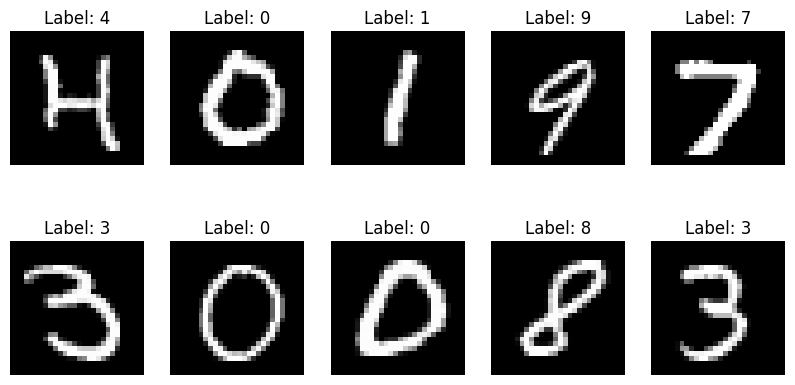

In [ ]:
plt.figure(figsize=(10, 5))

for images, labels in train_ds.take(1):
    for i in range(10):
        plt.subplot(2, 5, i + 1)
        plt.imshow(images[i].numpy().squeeze(), cmap="gray")
        plt.title(f"Label: {labels[i].numpy()}")
        plt.axis("off")

plt.show()

In [ ]:
model = Sequential()

model.add(
    Flatten(input_shape=(28, 28, 1))
)

model.add(
    Dense(
        units=256,
        activation="relu",
        kernel_initializer="uniform"
    )
)

model.add(
    Dense(
        units=128,
        activation="relu",
        kernel_initializer="uniform"
    )
)

model.add(
    Dense(
        units=10,
        activation="softmax",
        kernel_initializer="uniform"
    )
)

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_5 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    train_ds,
    epochs=20,
    validation_data=test_ds
)

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9246 - loss: 0.2535 - val_accuracy: 0.9593 - val_loss: 0.1299
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.9701 - loss: 0.0964 - val_accuracy: 0.9704 - val_loss: 0.0953
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.9799 - loss: 0.0636 - val_accuracy: 0.9708 - val_loss: 0.0990
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9863 - loss: 0.0433 - val_accuracy: 0.9725 - val_loss: 0.0952
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - accuracy: 0.9889 - loss: 0.0345 - val_accuracy: 0.9703 - val_loss: 0.1190
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.9912 - loss: 0.0269 - val_accuracy: 0.9754 - val_loss: 0.0921
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9926 - loss: 0.0222 - val_accuracy: 0.9756 - val_loss: 0.1017
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.9928 - los

In [ ]:
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="val")

plt.title("model accuracy")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.legend()
plt.show()

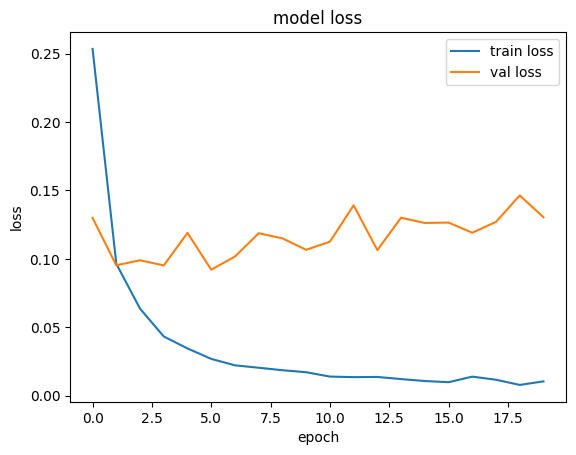

In [ ]:
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")

plt.title("model loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.show()

In [ ]:
test_loss, test_acc = model.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

In [ ]:
for images, labels in test_ds.take(1):
    predictions = model.predict(images)

    plt.figure(figsize=(12, 8))

    for i in range(20):
        pred = np.argmax(predictions[i])
        real = labels[i].numpy()

        plt.subplot(4, 5, i + 1)
        plt.imshow(images[i].numpy().squeeze(), cmap="gray")

        if pred == real:
            title = f"OK\nP:{pred} R:{real}"
        else:
            title = f"Wrong\nP:{pred} R:{real}"

        plt.title(title)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

## Cell 2: Load ảnh từ folder

In [ ]:
train_dir = "/content/MNIST/train"
test_dir = "/content/MNIST/test"

img_size = (28, 28)
batch_size = 32

train_ds = keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=img_size,
    color_mode="grayscale",
    batch_size=batch_size,
    label_mode="int"
)

test_ds = keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=img_size,
    color_mode="grayscale",
    batch_size=batch_size,
    label_mode="int"
)

class_names = train_ds.class_names

print("Class names:", class_names)

FileNotFoundError: [Errno 2] No such file or directory: '/content/MNIST/train'

In [ ]:
normalization_layer = keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))

## Cell 3: Scale dữ liệu

In [ ]:
normalization_layer = keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))

NameError: name 'train_ds' is not defined

In [ ]:
plt.figure(figsize=(10, 5))

for images, labels in train_ds.take(1):
    for i in range(10):
        plt.subplot(2, 5, i + 1)
        plt.imshow(images[i].numpy().squeeze(), cmap="gray")
        plt.title(f"Label: {labels[i].numpy()}")
        plt.axis("off")

plt.show()

## Cell 4: Hiển thị ảnh mẫu

In [ ]:
plt.figure(figsize=(10, 5))

for images, labels in train_ds.take(1):
    for i in range(10):
        plt.subplot(2, 5, i + 1)
        plt.imshow(images[i].numpy().squeeze(), cmap="gray")
        plt.title(f"Label: {labels[i].numpy()}")
        plt.axis("off")

plt.show()

NameError: name 'train_ds' is not defined

<Figure size 1000x500 with 0 Axes>

In [ ]:
model = Sequential()

model.add(
    Flatten(input_shape=(28, 28, 1))
)

model.add(
    Dense(
        units=256,
        activation="relu",
        kernel_initializer="uniform"
    )
)

model.add(
    Dense(
        units=128,
        activation="relu",
        kernel_initializer="uniform"
    )
)

model.add(
    Dense(
        units=10,
        activation="softmax",
        kernel_initializer="uniform"
    )
)

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

## Cell 5: Build ANN

In [ ]:
model = Sequential()

model.add(
    Flatten(input_shape=(28, 28, 1))
)

model.add(
    Dense(
        units=256,
        activation="relu",
        kernel_initializer="uniform"
    )
)

model.add(
    Dense(
        units=128,
        activation="relu",
        kernel_initializer="uniform"
    )
)

model.add(
    Dense(
        units=10,
        activation="softmax",
        kernel_initializer="uniform"
    )
)

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    train_ds,
    epochs=20,
    validation_data=test_ds
)

## Cell 6: Train

In [ ]:
history = model.fit(
    train_ds,
    epochs=20,
    validation_data=test_ds
)

NameError: name 'train_ds' is not defined

In [ ]:
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="val")

plt.title("model accuracy")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.legend()
plt.show()

## Cell 7: Biểu đồ Accuracy

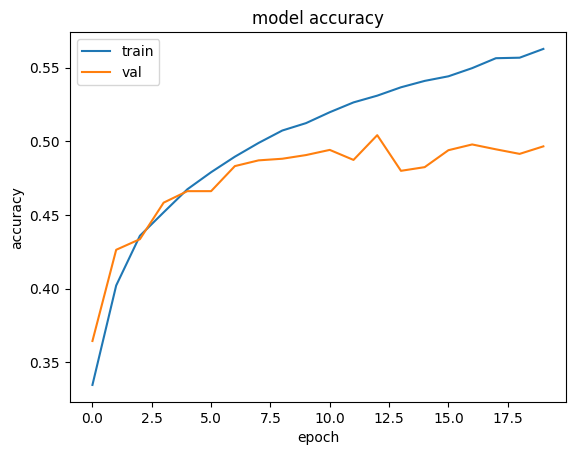

In [ ]:
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="val")

plt.title("model accuracy")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.legend()
plt.show()

In [ ]:
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")

plt.title("model loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.show()

## Cell 8: Biểu đồ Loss

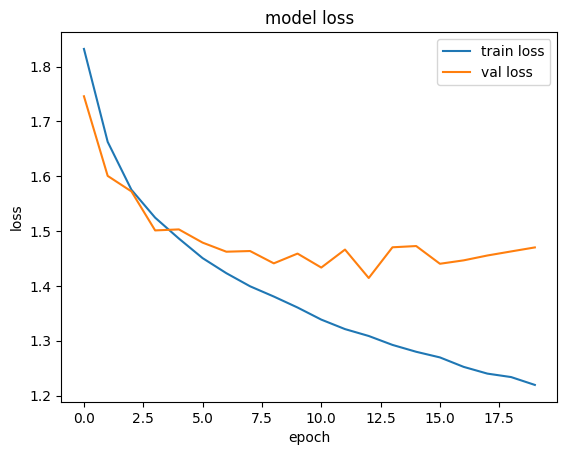

In [ ]:
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")

plt.title("model loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.show()

In [ ]:
test_loss, test_acc = model.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

## Cell 9: Evaluate

In [ ]:
test_loss, test_acc = model.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

NameError: name 'test_ds' is not defined

In [ ]:
for images, labels in test_ds.take(1):
    predictions = model.predict(images)

    plt.figure(figsize=(12, 8))

    for i in range(20):
        pred = np.argmax(predictions[i])
        real = labels[i].numpy()

        plt.subplot(4, 5, i + 1)
        plt.imshow(images[i].numpy().squeeze(), cmap="gray")

        if pred == real:
            title = f"OK\nP:{pred} R:{real}"
        else:
            title = f"Wrong\nP:{pred} R:{real}"

        plt.title(title)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

## Cell 10: Predict ảnh mẫu

In [ ]:
for images, labels in test_ds.take(1):
    predictions = model.predict(images)

    plt.figure(figsize=(12, 8))

    for i in range(20):
        pred = np.argmax(predictions[i])
        real = labels[i].numpy()

        plt.subplot(4, 5, i + 1)
        plt.imshow(images[i].numpy().squeeze(), cmap="gray")

        if pred == real:
            title = f"OK\nP:{pred} R:{real}"
        else:
            title = f"Wrong\nP:{pred} R:{real}"

        plt.title(title)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

NameError: name 'test_ds' is not defined